In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer, TfidfTransformer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import make_pipeline
from sklearn.metrics import classification_report, accuracy_score,precision_score,recall_score,f1_score, ConfusionMatrixDisplay, confusion_matrix
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.ensemble import VotingClassifier
import matplotlib.pyplot as plt
from collections import Counter
import tiktoken
import seaborn as sns
from spacy.lang.fr.stop_words import STOP_WORDS as fr_stop
from spacy.lang.en.stop_words import STOP_WORDS as en_stop
from nltk import word_tokenize          
from nltk.stem import WordNetLemmatizer 
from project.classification.utils import train_test

# Processing data

In [2]:
# Variable
percentage_genre_to_keep = 25


In [3]:
df = pd.read_csv("./data/MovieDataThread.csv")
index_drop = df.loc[df['imdb_id'].isnull()].index
df = df.drop(index=index_drop)
df = df.drop(columns=['imdb_id'])
df_filtered = pd.concat([df[['Script','Title']],df.filter(like='imdb_')],axis=1)


In [4]:
df_filtered["genre_count"] = df_filtered.filter(regex='^imdb_(?!id$)').count(axis=1)
df_filtered_one_genre = df_filtered.loc[df_filtered['genre_count'] == 1]
print(df_filtered_one_genre.shape)
df_filtered_one_genre.head()

(8753, 31)


,Script,Title,imdb_action,imdb_adventure,imdb_animation,imdb_biography,imdb_comedy,imdb_crime,imdb_documentary,imdb_drama,...,imdb_romance,imdb_sci-fi,imdb_short,imdb_sport,imdb_talk-show,imdb_thriller,imdb_war,imdb_western,imdb_adult,genre_count
0,So what's goin' on?\n Where's my brother?\n So...,Beyond the Dunwich Horror (2008),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
3,"Like this?\n Good.\n Okay, that's good.\n Righ...",Beyond the Gates (2016),NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
5,1\n Beyond the hills\n Stay there!\n Voichita!...,Beyond the Hills (2012),NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
23,"Sir, this place is so dusty.\n Hmm.\n Your cho...",Bhagavan Dasante Ramrajyam (2023),NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
28,"1\n 'Ronapura's own living God, Bhairathi\n Ra...",Bhairathi Ranagal (2024),NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1


In [5]:
df_filtered_one_genre['filtered_genre'] = df_filtered_one_genre.apply(lambda row: next(iter([col for col in df_filtered_one_genre.columns if "imdb" in col and row[col] == 1.0 ]), 'unknown'), axis=1)
df_filtered_one_genre['filtered_genre']


/tmp/ipykernel_79626/707917607.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered_one_genre['filtered_genre'] = df_filtered_one_genre.apply(lambda row: next(iter([col for col in df_filtered_one_genre.columns if "imdb" in col and row[col] == 1.0 ]), 'unknown'), axis=1)


0             imdb_horror
3              imdb_drama
5              imdb_drama
23             imdb_drama
28             imdb_drama
               ...       
38115          imdb_drama
38123    imdb_documentary
38125          imdb_drama
38133      imdb_adventure
38134          imdb_drama
Name: filtered_genre, Length: 8753, dtype: object

In [6]:
df_filtered_one_genre['filtered_genre'].value_counts()


filtered_genre
imdb_drama          2948
imdb_comedy         1622
imdb_documentary    1301
imdb_horror          944
imdb_thriller        643
imdb_romance         262
imdb_action          242
imdb_western         112
imdb_family          112
imdb_sci-fi           79
imdb_crime            61
imdb_animation        56
imdb_talk-show        51
imdb_music            50
imdb_short            49
imdb_mystery          49
imdb_adventure        37
imdb_fantasy          27
imdb_reality-tv       21
imdb_musical          21
imdb_war              16
imdb_biography        16
imdb_sport            12
imdb_game-show         8
imdb_news              8
imdb_history           6
Name: count, dtype: int64

/tmp/ipykernel_79626/3269823211.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count', y='Genre', data=df_counts, palette="viridis")


Text(0, 0.5, 'Genres')

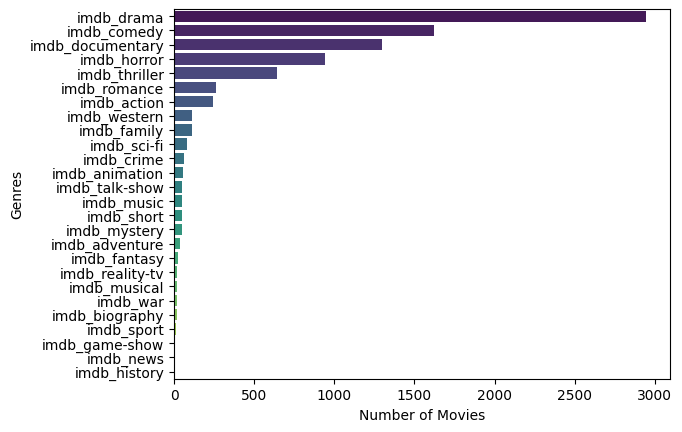

In [7]:

df_counts = df_filtered_one_genre['filtered_genre'].value_counts().reset_index()
df_counts.columns = ['Genre', 'Count']

sns.barplot(x='Count', y='Genre', data=df_counts, palette="viridis")

plt.xlabel('Number of Movies')
plt.ylabel('Genres')


In [8]:
number_genres = len(df_filtered_one_genre['filtered_genre'].unique())
counter = Counter(df_filtered_one_genre['filtered_genre'])

In [9]:
sorted_list = sorted(counter.items(),reverse=True , key=lambda genre : genre[1])[: int(number_genres * (percentage_genre_to_keep / 100))]

for genre,number in sorted_list:
    print(f"Genre: {genre}, number of samples: {number}")

genre_to_keep = [genre for genre,_ in sorted_list]
genre_to_keep

Genre: imdb_drama, number of samples: 2948
Genre: imdb_comedy, number of samples: 1622
Genre: imdb_documentary, number of samples: 1301
Genre: imdb_horror, number of samples: 944
Genre: imdb_thriller, number of samples: 643
Genre: imdb_romance, number of samples: 262


['imdb_drama',
 'imdb_comedy',
 'imdb_documentary',
 'imdb_horror',
 'imdb_thriller',
 'imdb_romance']

In [10]:
columns_to_keep = ['Script','filtered_genre']

df_filtered_one_genre_to_train = df_filtered_one_genre.loc[df_filtered_one_genre['filtered_genre'].isin(genre_to_keep)]
df_filtered_one_genre_to_train = df_filtered_one_genre_to_train[columns_to_keep].reset_index(drop=True)
df_filtered_one_genre_to_train

,Script,filtered_genre
0,So what's goin' on?\n Where's my brother?\n So...,imdb_horror
1,"Like this?\n Good.\n Okay, that's good.\n Righ...",imdb_drama
2,1\n Beyond the hills\n Stay there!\n Voichita!...,imdb_drama
3,"Sir, this place is so dusty.\n Hmm.\n Your cho...",imdb_drama
4,"1\n 'Ronapura's own living God, Bhairathi\n Ra...",imdb_drama
...,...,...
7715,"Here in Malaysia, there is an almost\n overwhe...",imdb_comedy
7716,"Okay, let's go for a take\n Get ready to carry...",imdb_drama
7717,Turn left.\n Make a right.\n Is this the kitch...,imdb_documentary
7718,Are you going somewhere? No?\n Last week I was...,imdb_drama


# Training and test

In [11]:
def lemma_tokenize(doc):
    wnl = WordNetLemmatizer()
    return [wnl.lemmatize(t) for t in word_tokenize(doc)]

def char_tokenize(doc):
    return [char for char in doc]

def byte_tokenize(doc):
    tokens = doc.encode("utf-8")
    tokens = list(map(int, tokens))
    return [str(token) for token in tokens]

def gpt_tokenize(doc):
    enc = tiktoken.encoding_for_model("gpt-4")
    tokens = enc.encode(doc)
    return [str(token) for token in tokens]

/home/alexis/epita/nlp/myenv/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Model: LogisticRegression with unigram
Features dimension: (6176, 200664)
Classification Report unbalanced:
                   precision    recall  f1-score   support

     imdb_comedy       0.75      0.71      0.73       314
imdb_documentary       0.87      0.88      0.87       251
      imdb_drama       0.75      0.82      0.78       609
     imdb_horror       0.72      0.75      0.74       171
    imdb_romance       0.65      0.49      0.56        61
   imdb_thriller       0.62      0.46      0.53       138

        accuracy                           0.75      1544
       macro avg       0.73      0.68      0.70      1544
    weighted avg       0.75      0.75      0.75      1544

LogisticRegression(max_iter=500)
Top 15 mots pour la classe 'imdb_comedy': ['great' 'sex' 'stella' 'ho' 'ass' 'thought' 'cause' 'gentlemen' 'movie'
 'watch' 'find' 've' 'said' 'hot' 'ladies']
Top 15 mots pour la classe 'imdb_documentary': ['problem' 'wanna' 'many' 'give' 'better' 'push' 'paige' 'hello' 'gir

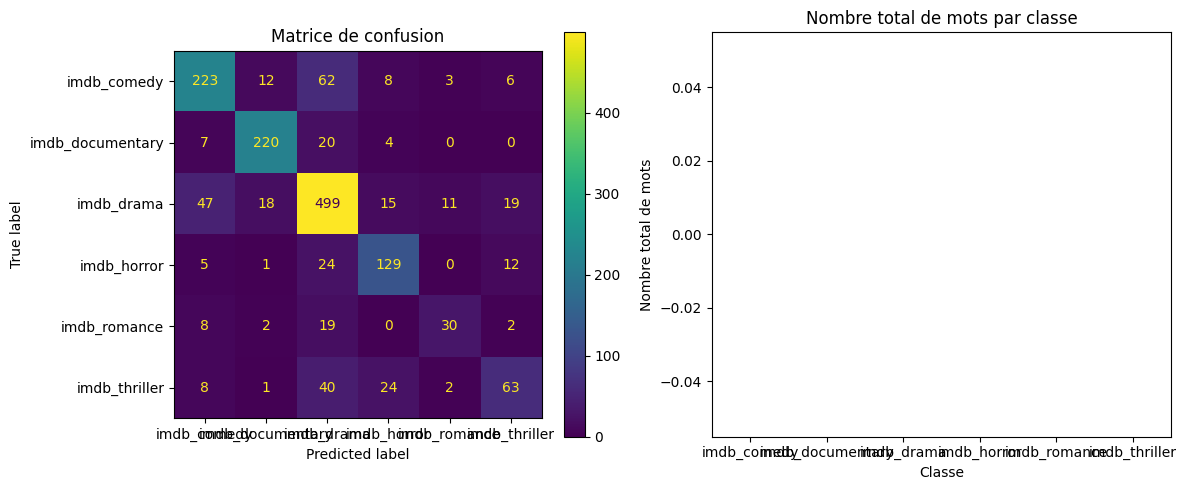

In [12]:
model = make_pipeline(CountVectorizer(ngram_range = (1,1)), LogisticRegression(max_iter=500))
train_test(model,df_filtered_one_genre_to_train,plots=["matrix","avg_words","top_words"],desc="LogisticRegression with unigram")


/home/alexis/epita/nlp/myenv/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Model: LogisticRegression with unigram
Features dimension: (1257, 81831)
Classification Report balanced:
                   precision    recall  f1-score   support

     imdb_comedy       0.66      0.69      0.67        55
imdb_documentary       0.91      0.87      0.89        60
      imdb_drama       0.71      0.60      0.65        60
     imdb_horror       0.75      0.80      0.77        51
    imdb_romance       0.74      0.81      0.77        42
   imdb_thriller       0.54      0.55      0.55        47

        accuracy                           0.72       315
       macro avg       0.72      0.72      0.72       315
    weighted avg       0.72      0.72      0.72       315

LogisticRegression()
Top 15 mots pour la classe 'imdb_comedy': ['my' 'people' 'is' 'daniel' 'look' 'audience' 'said' 'got' 'an' 'guys'
 'now' 'say' 'like' 'right' 'oh']
Top 15 mots pour la classe 'imdb_documentary': ['speaking' 'caleb' 'when' 'see' '00' 'girl' 'sasha' 'that' 'how' 'tom'
 'tony' 'want' 'are' 'o

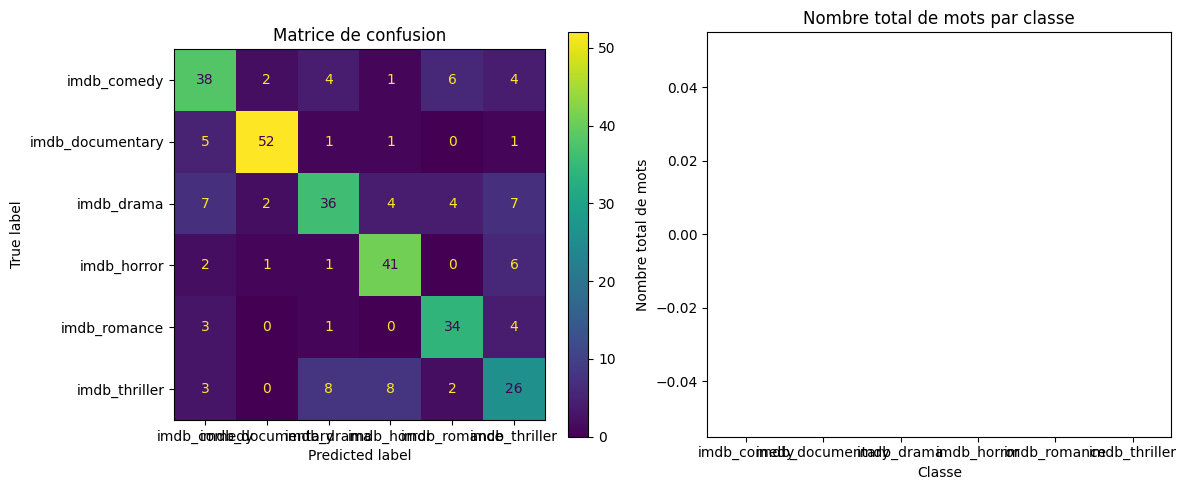

In [13]:
model = make_pipeline(CountVectorizer(ngram_range = (1,1)), LogisticRegression())
train_test(model,df_filtered_one_genre_to_train,plots=["matrix","avg_words","top_words"],desc="LogisticRegression with unigram",equilibrate=True)




In [14]:
#model = make_pipeline(CountVectorizer(ngram_range = (1,2)), LogisticRegression())
#train_test(model,df_filtered_one_genre_to_train,plots=["matrix","avg_words","top_words"],desc="LogisticRegression with unigram and bigram")


In [15]:
#model = make_pipeline(CountVectorizer(ngram_range = (1,2)), LogisticRegression())
#train_test(model,df_filtered_one_genre_to_train,plots=["matrix","avg_words","top_words"],desc="LogisticRegression with unigram and bigram",equilibrate=True)


In [16]:
#model = make_pipeline(CountVectorizer(ngram_range = (2,2)), LogisticRegression())
#train_test(model,df_filtered_one_genre_to_train,plots=["matrix","avg_words","top_words"],desc="LogisticRegression with bigram")



In [ ]:
#emodel = make_pipeline(CountVectorizer(ngram_range = (2,2)), LogisticRegression())
#train_test(model,df_filtered_one_genre_to_train,plots=["matrix","avg_words","top_words"],desc="LogisticRegression with bigram",equilibrate=True)


/home/alexis/epita/nlp/myenv/lib/python3.10/site-packages/sklearn/feature_extraction/text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['ll', 've'] not in stop_words.
  warnings.warn(
/home/alexis/epita/nlp/myenv/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Model: LogisticRegression with unigranne and stop words in english
Features dimension: (6176, 200363)
Classification Report unbalanced:
                   precision    recall  f1-score   support

     imdb_comedy       0.73      0.73      0.73       314
imdb_documentary       0.87      0.89      0.88       251
      imdb_drama       0.75      0.83      0.79       609
     imdb_horror       0.81      0.80      0.80       171
    imdb_romance       0.79      0.49      0.61        61
   imdb_thriller       0.65      0.46      0.54       138

        accuracy                           0.77      1544
       macro avg       0.77      0.70      0.73      1544
    weighted avg       0.77      0.77      0.76      1544

LogisticRegression()
Top 15 mots pour la classe 'imdb_comedy': ['wait' 'lady' 'nora' 'find' 'cause' 'ass' 'gentlemen' 'ladies' 'thought'
 'teacher' 'dick' 'movie' 'balls' 'hot' 'captain']
Top 15 mots pour la classe 'imdb_documentary': ['money' 'different' 'change' 'war' 'phone' '

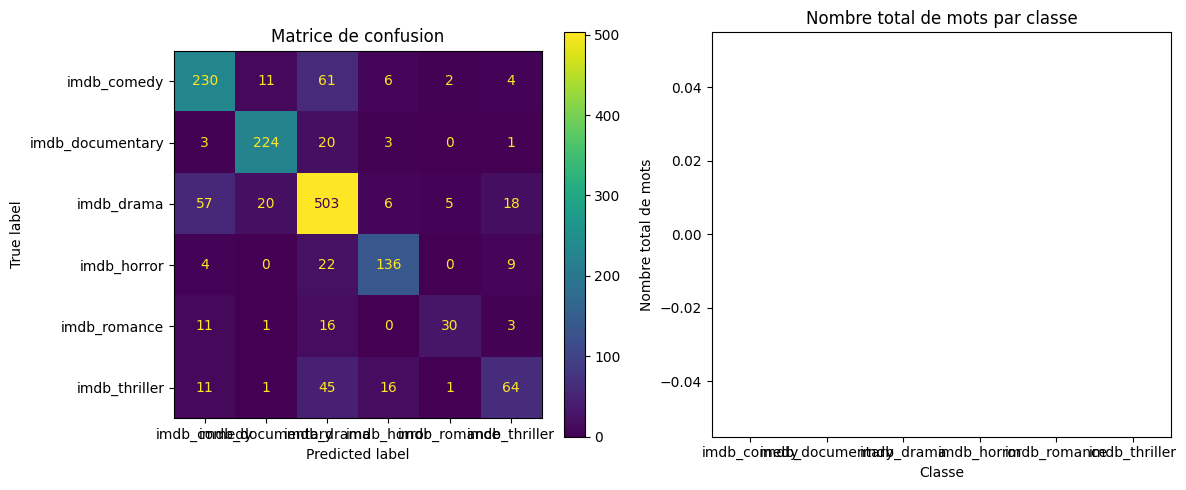

In [18]:
model = make_pipeline(CountVectorizer(ngram_range = (1,1), stop_words = list(en_stop)), LogisticRegression())
train_test(model,df_filtered_one_genre_to_train,plots=["matrix","avg_words","top_words"],desc="LogisticRegression with unigranne and stop words in english")



/home/alexis/epita/nlp/myenv/lib/python3.10/site-packages/sklearn/feature_extraction/text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['ll', 've'] not in stop_words.
  warnings.warn(
/home/alexis/epita/nlp/myenv/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Model: LogisticRegression with unigranne and stop words in english
Features dimension: (1257, 83767)
Classification Report balanced:
                   precision    recall  f1-score   support

     imdb_comedy       0.77      0.60      0.67        55
imdb_documentary       0.94      0.83      0.88        60
      imdb_drama       0.54      0.55      0.55        60
     imdb_horror       0.77      0.84      0.80        51
    imdb_romance       0.69      0.86      0.77        42
   imdb_thriller       0.66      0.70      0.68        47

        accuracy                           0.72       315
       macro avg       0.73      0.73      0.73       315
    weighted avg       0.73      0.72      0.72       315

LogisticRegression()
Top 15 mots pour la classe 'imdb_comedy': ['laughter' 'malice' 'hate' 'dick' 'shakespeare' 'gentlemen' 'gave' 'mr'
 'oh' 'guys' 'shit' 'ass' 'mishy' 'car' 'great']
Top 15 mots pour la classe 'imdb_documentary': ['abbie' 'lot' 'carson' 'years' 'way' 'jake' 'light

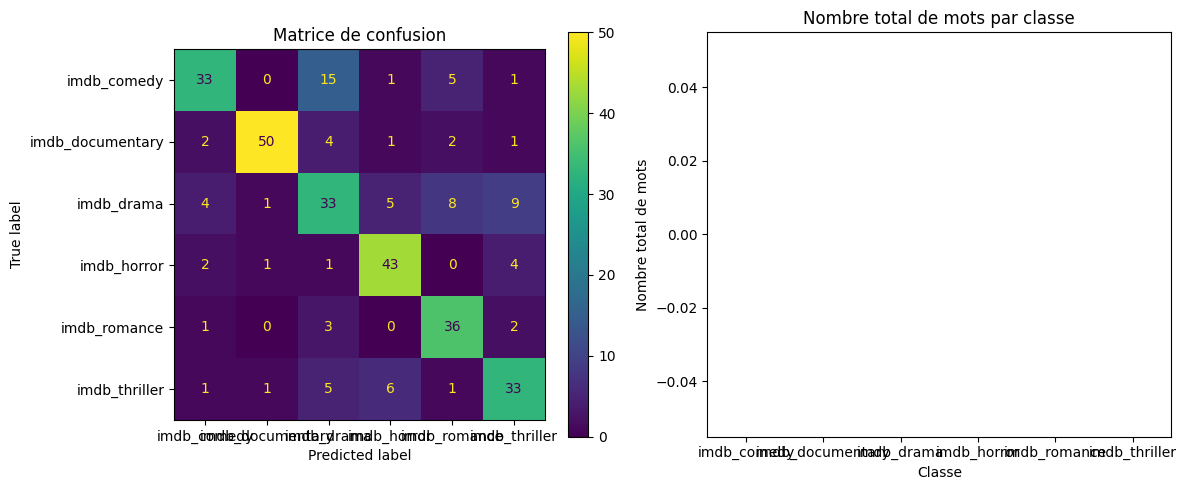

In [19]:
model = make_pipeline(CountVectorizer(ngram_range = (1,1), stop_words = list(en_stop)), LogisticRegression())
train_test(model,df_filtered_one_genre_to_train,plots=["matrix","avg_words","top_words"],desc="LogisticRegression with unigranne and stop words in english",equilibrate=True)



/home/alexis/epita/nlp/myenv/lib/python3.10/site-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
/home/alexis/epita/nlp/myenv/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Model: LogisticRegression with word_tokenize
Features dimension: (6176, 299686)
Classification Report unbalanced:
                   precision    recall  f1-score   support

     imdb_comedy       0.73      0.73      0.73       314
imdb_documentary       0.91      0.86      0.88       251
      imdb_drama       0.73      0.81      0.77       609
     imdb_horror       0.67      0.68      0.68       171
    imdb_romance       0.71      0.48      0.57        61
   imdb_thriller       0.61      0.43      0.51       138

        accuracy                           0.74      1544
       macro avg       0.73      0.67      0.69      1544
    weighted avg       0.74      0.74      0.74      1544

LogisticRegression()
Top 15 mots pour la classe 'imdb_comedy': ['now' 'guy' 'say' 'because' 'right' 'we' 'guys' 'get' 'not' 'got' 'yes'
 'like' 'my' 'a' 'oh']
Top 15 mots pour la classe 'imdb_documentary': ['want' 'one' '|' 'or' '#' 'na' 'it' 'go' 'how' 'are' 'when' 'like' 'do'
 'they' 'to']
Top 15 mo

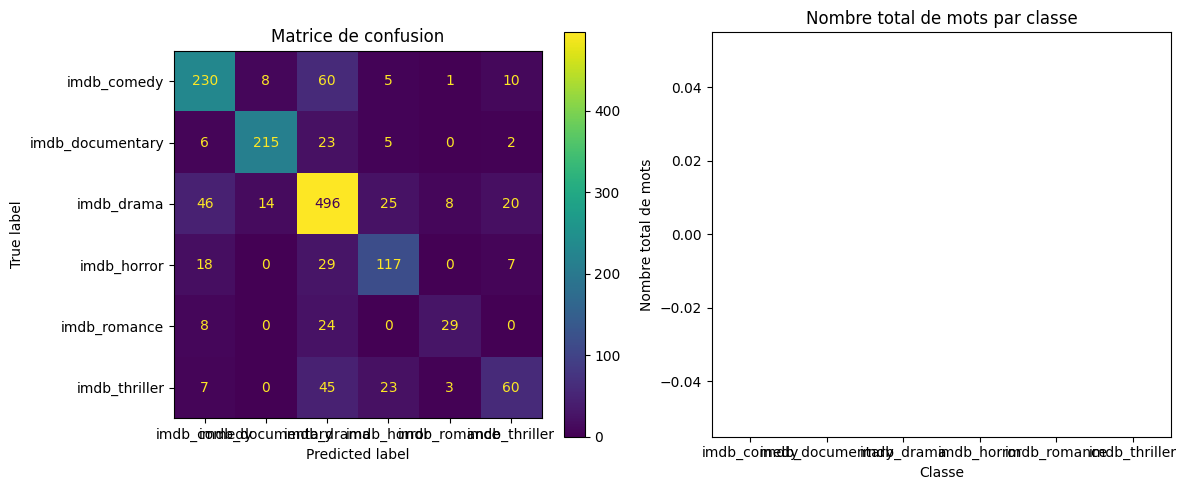

In [20]:
model = make_pipeline(CountVectorizer(tokenizer=word_tokenize), LogisticRegression())
train_test(model,df_filtered_one_genre_to_train,plots=["matrix","avg_words","top_words"],desc="LogisticRegression with word_tokenize")


/home/alexis/epita/nlp/myenv/lib/python3.10/site-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
/home/alexis/epita/nlp/myenv/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Model: LogisticRegression with word_tokenize
Features dimension: (1257, 111152)
Classification Report balanced:
                   precision    recall  f1-score   support

     imdb_comedy       0.57      0.53      0.55        55
imdb_documentary       0.86      0.73      0.79        60
      imdb_drama       0.52      0.43      0.47        60
     imdb_horror       0.68      0.63      0.65        51
    imdb_romance       0.57      0.74      0.65        42
   imdb_thriller       0.39      0.51      0.44        47

        accuracy                           0.59       315
       macro avg       0.60      0.60      0.59       315
    weighted avg       0.61      0.59      0.59       315

LogisticRegression()
Top 15 mots pour la classe 'imdb_comedy': ['get' 'and' 'man' '``' "'m" 'money' 'that' 'laughter' 'is' "'re" 'not'
 'yes' 'oh' 'a' 'my']
Top 15 mots pour la classe 'imdb_documentary': ['this' 'na' 'they' ':' 'people' 'of' 'madame' 'here' 'do' 'was' 'like'
 'l' 'elise' 'it' 'and']
Top

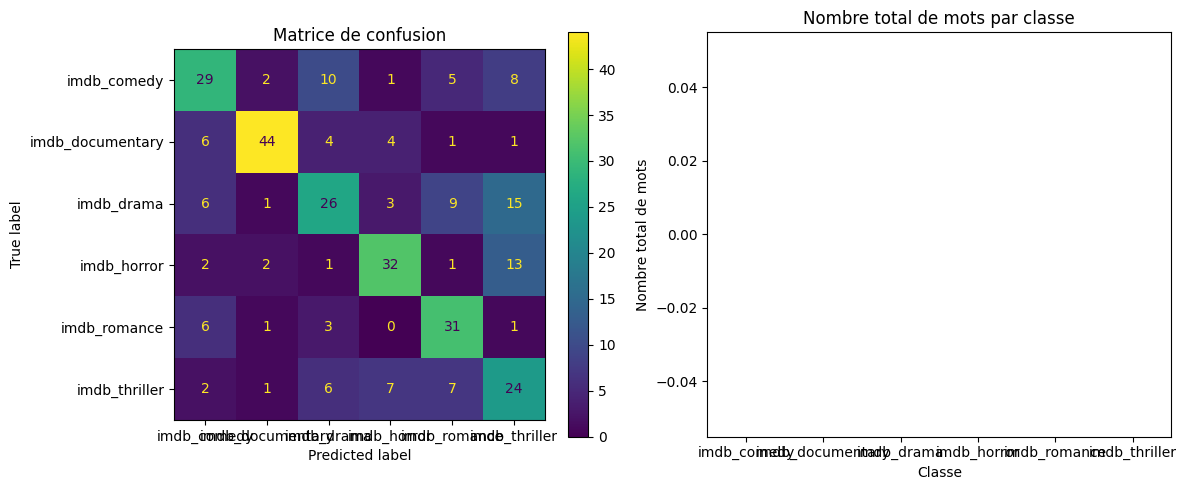

In [21]:
model = make_pipeline(CountVectorizer(tokenizer=word_tokenize), LogisticRegression())
train_test(model,df_filtered_one_genre_to_train,plots=["matrix","avg_words","top_words"],desc="LogisticRegression with word_tokenize",equilibrate=True)


/home/alexis/epita/nlp/myenv/lib/python3.10/site-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
/home/alexis/epita/nlp/myenv/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Model: LogisticRegression with lemma_tokenize
Features dimension: (6176, 285326)
Classification Report unbalanced:
                   precision    recall  f1-score   support

     imdb_comedy       0.76      0.71      0.73       314
imdb_documentary       0.91      0.85      0.88       251
      imdb_drama       0.72      0.83      0.77       609
     imdb_horror       0.69      0.68      0.69       171
    imdb_romance       0.68      0.46      0.55        61
   imdb_thriller       0.59      0.46      0.52       138

        accuracy                           0.75      1544
       macro avg       0.73      0.67      0.69      1544
    weighted avg       0.74      0.75      0.74      1544

LogisticRegression()
Top 15 mots pour la classe 'imdb_comedy': ['now' 'your' 'say' 'right' 'we' 'because' 'not' 'get' 'got' 'yes' 'a'
 'like' 'guy' 'my' 'oh']
Top 15 mots pour la classe 'imdb_documentary': ['go' 'one' 'feel' 'or' 'it' '#' 'na' 'want' 'how' 'are' 'when' 'like'
 'to' 'do' 'they']
Top 1

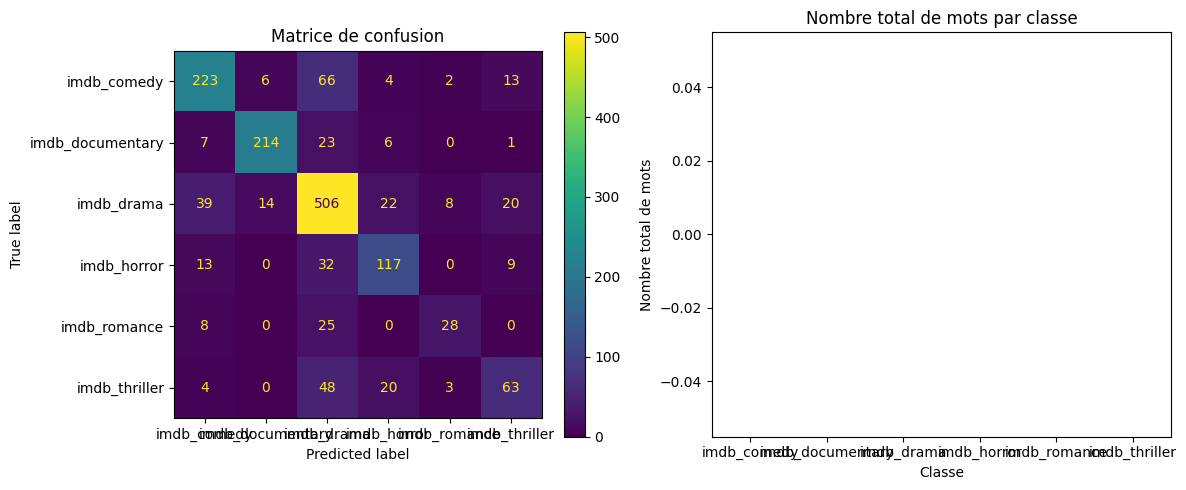

In [22]:
model = make_pipeline(CountVectorizer(tokenizer=lemma_tokenize, ngram_range = (1,1)), LogisticRegression())
train_test(model,df_filtered_one_genre_to_train,plots=["matrix","avg_words","top_words"],desc="LogisticRegression with lemma_tokenize")

/home/alexis/epita/nlp/myenv/lib/python3.10/site-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
/home/alexis/epita/nlp/myenv/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Model: LogisticRegression with lemma_tokenize
Features dimension: (1257, 105897)
Classification Report balanced:
                   precision    recall  f1-score   support

     imdb_comedy       0.71      0.62      0.66        55
imdb_documentary       0.83      0.88      0.85        60
      imdb_drama       0.50      0.52      0.51        60
     imdb_horror       0.74      0.76      0.75        51
    imdb_romance       0.66      0.69      0.67        42
   imdb_thriller       0.61      0.57      0.59        47

        accuracy                           0.68       315
       macro avg       0.67      0.67      0.67       315
    weighted avg       0.68      0.68      0.67       315

LogisticRegression()
Top 15 mots pour la classe 'imdb_comedy': ['sex' 'will' 'mr.' 'audience' 'ticket' 'brother' "'re" 'get' 'we' 'yes'
 'guy' '|' 'a' 'my' 'oh']
Top 15 mots pour la classe 'imdb_documentary': ['to' 'when' 'he' 'are' "'" 'they' 'them' 'want' 'or' 'and' 'of' 'gon'
 'like' 'money' 'na']
T

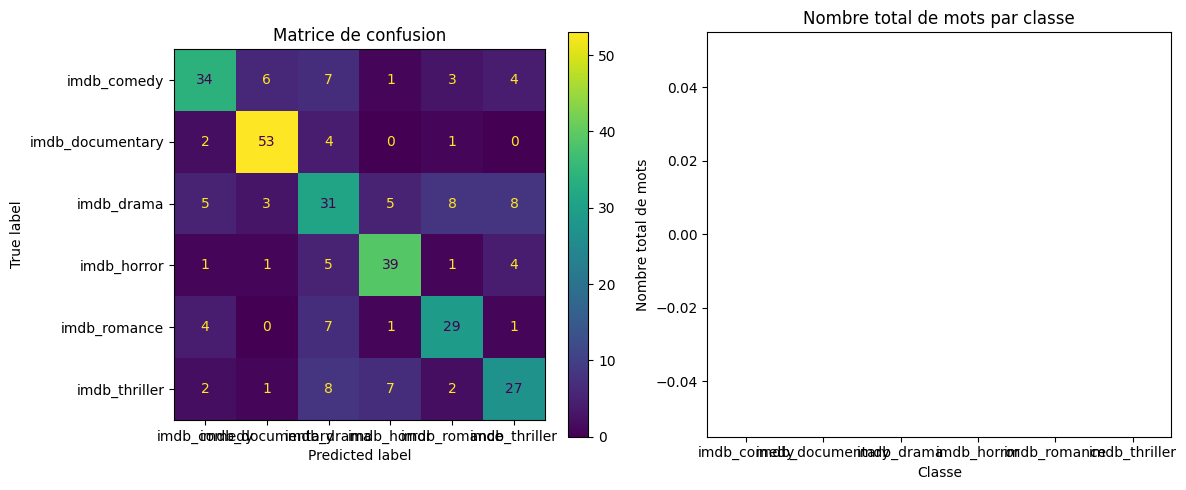

In [23]:
model = make_pipeline(CountVectorizer(tokenizer=lemma_tokenize, ngram_range = (1,1)), LogisticRegression())
train_test(model,df_filtered_one_genre_to_train,plots=["matrix","avg_words","top_words"],desc="LogisticRegression with lemma_tokenize",equilibrate=True)

In [24]:
model = make_pipeline(CountVectorizer(ngram_range = (1,1)), LogisticRegression(alpha=0.08))
train_test(model,df_filtered_one_genre_to_train,plots=["matrix","avg_words","top_words"],desc="LogisticRegression with unigram and laplacian alpha = 0.08")

TypeError: LogisticRegression.__init__() got an unexpected keyword argument 'alpha'

Model: MultinomialNB with unigram and laplacian alpha = 0.08
Features dimension: (1257, 83272)
Classification Report balanced:
                   precision    recall  f1-score   support

     imdb_comedy       0.55      0.60      0.57        55
imdb_documentary       0.91      0.88      0.90        60
      imdb_drama       0.55      0.60      0.57        60
     imdb_horror       0.70      0.51      0.59        51
    imdb_romance       0.70      0.76      0.73        42
   imdb_thriller       0.48      0.49      0.48        47

        accuracy                           0.64       315
       macro avg       0.65      0.64      0.64       315
    weighted avg       0.65      0.64      0.65       315

Top 15 mots pour la classe 'imdb_comedy': ['on' 'this' 'my' 'we' 'me' 'in' 'of' 'what' 'is' 'that' 'and' 'it' 'to'
 'the' 'you']
Top 15 mots pour la classe 'imdb_documentary': ['for' 'this' 'he' 'they' 'we' 'is' 'was' 'in' 'it' 'that' 'you' 'of' 'to'
 'and' 'the']
Top 15 mots pour la clas

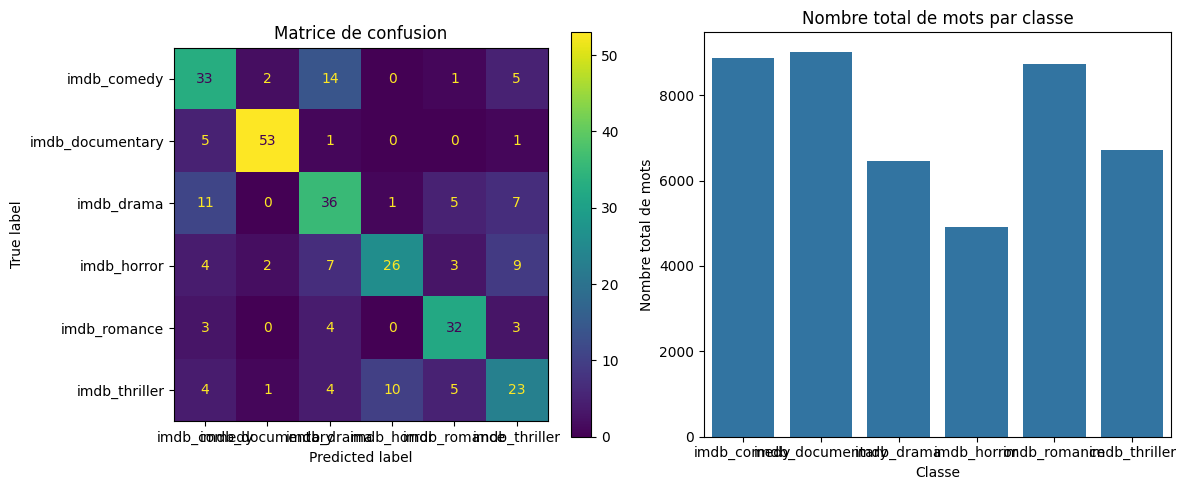

In [ ]:
model = make_pipeline(CountVectorizer(ngram_range = (1,1)), LogisticRegression(alpha=0.08))
train_test(model,df_filtered_one_genre_to_train,plots=["matrix","avg_words","top_words"],desc="LogisticRegression with unigram and laplacian alpha = 0.08",equilibrate=True)

Model: MultinomialNB with tf idf
Features dimension: (6176, 200664)
Classification Report unbalanced:
                   precision    recall  f1-score   support

     imdb_comedy       0.80      0.11      0.20       314
imdb_documentary       0.95      0.55      0.69       251
      imdb_drama       0.45      0.99      0.62       609
     imdb_horror       1.00      0.04      0.08       171
    imdb_romance       0.00      0.00      0.00        61
   imdb_thriller       0.00      0.00      0.00       138

        accuracy                           0.51      1544
       macro avg       0.53      0.28      0.26      1544
    weighted avg       0.60      0.51      0.41      1544



/home/alexis/epita/nlp/myenv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/alexis/epita/nlp/myenv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/alexis/epita/nlp/myenv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(resu

Top 15 mots pour la classe 'imdb_comedy': ['on' 'this' 'my' 'me' 'we' 'in' 'what' 'is' 'of' 'that' 'and' 'it' 'to'
 'the' 'you']
Top 15 mots pour la classe 'imdb_documentary': ['for' 'he' 'they' 'this' 'we' 'was' 'is' 'in' 'that' 'it' 'you' 'of' 'to'
 'and' 'the']
Top 15 mots pour la classe 'imdb_drama': ['for' 'this' 'my' 'we' 'in' 'is' 'of' 'me' 'what' 'that' 'and' 'it' 'to'
 'the' 'you']
Top 15 mots pour la classe 'imdb_horror': ['on' 'no' 'this' 'in' 'is' 'me' 'we' 'of' 'what' 'and' 'that' 'it' 'to'
 'the' 'you']
Top 15 mots pour la classe 'imdb_romance': ['my' 'for' 'in' 'this' 'we' 'me' 'of' 'what' 'is' 'that' 'and' 'it' 'to'
 'the' 'you']
Top 15 mots pour la classe 'imdb_thriller': ['my' 'no' 'this' 'in' 'we' 'of' 'is' 'me' 'what' 'and' 'that' 'it' 'to'
 'the' 'you']


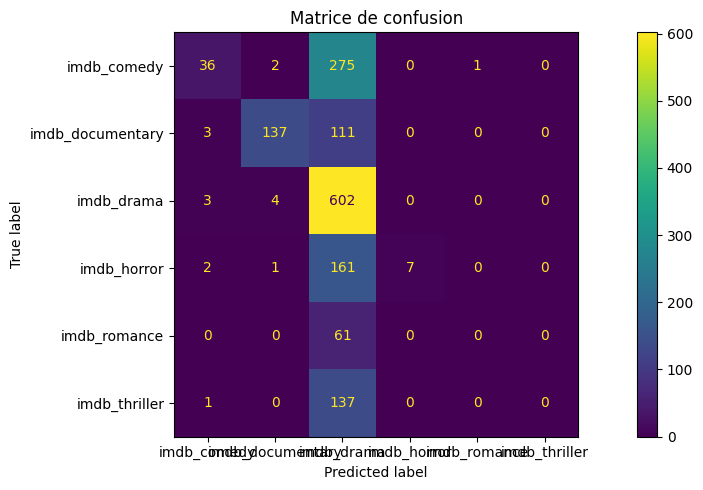

In [ ]:
model = make_pipeline(TfidfVectorizer(), LogisticRegression(alpha=0.05))
train_test(model,df_filtered_one_genre_to_train,plots=["matrix","top_words"],desc="LogisticRegression with tf idf")

/home/alexis/epita/nlp/myenv/lib/python3.10/site-packages/sklearn/feature_extraction/text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['ll', 've'] not in stop_words.
  warnings.warn(


Model: MultinomialNB with tf idf
Features dimension: (1257, 81111)
Classification Report balanced:
                   precision    recall  f1-score   support

     imdb_comedy       0.52      0.65      0.58        55
imdb_documentary       0.88      0.82      0.84        60
      imdb_drama       0.50      0.25      0.33        60
     imdb_horror       0.69      0.53      0.60        51
    imdb_romance       0.54      0.88      0.67        42
   imdb_thriller       0.54      0.60      0.57        47

        accuracy                           0.61       315
       macro avg       0.61      0.62      0.60       315
    weighted avg       0.62      0.61      0.60       315

Top 15 mots pour la classe 'imdb_comedy': ['let' 'think' 'gonna' 've' 'good' 'got' 'come' 'll' 'okay' 'right' 'yeah'
 'oh' 'know' 'like' 'don']
Top 15 mots pour la classe 'imdb_documentary': ['good' 'want' 'said' 'yeah' 'got' 'come' 'right' 'going' 've' 'time'
 'think' 'don' 'people' 'know' 'like']
Top 15 mots pour 

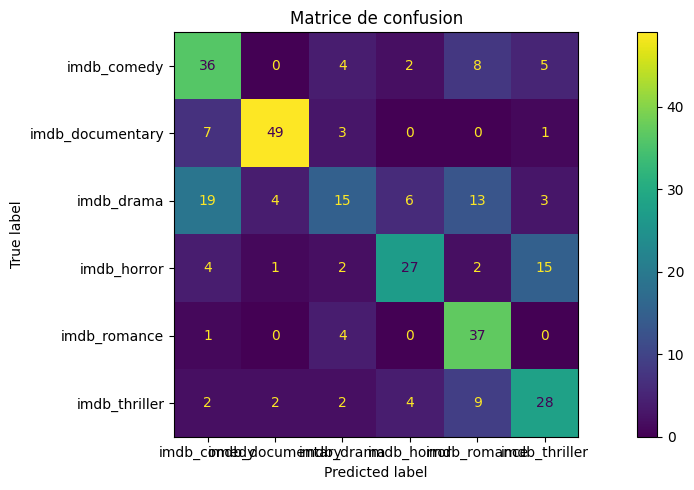

In [ ]:
model = make_pipeline(TfidfVectorizer(stop_words=list(en_stop)), LogisticRegression(alpha=0.05))
train_test(model,df_filtered_one_genre_to_train,plots=["matrix","top_words"],desc="LogisticRegression with tf idf",equilibrate=True)